In [16]:
import pandas as pd
import pedpy
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
csv_file0 = "app_data/proximity_analysis_results0.csv"
csv_file = "app_data/proximity_analysis_results.csv"

In [2]:
euc = pd.read_csv(csv_file0)
arc = pd.read_csv(csv_file)

In [28]:
import glob
pals = glob.glob('data/pal/*.csv')
for pal in pals:
    df = pd.read_csv(pal)
    print(type(df["frame"].max()))

<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>
<class 'numpy.int64'>


## Plot distance vs N in 4 different subfigures per type

In [3]:
def plot_distance_comparison_by_type(df, country, output_pdf, method):
    """
    Plot distance comparison by type for a given country and save the plot to a PDF file.

    Parameters:
    - df: DataFrame containing the data.
    - country: The country to filter the data by.
    - output_pdf: The path to save the output PDF file.
    """
    fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    fig.suptitle(f'Distance Comparison per Type for {country.title()}')

    types = sorted(df["type"].unique())
    for i, type_ in enumerate(types):
        # Extract 'N' values directly within the loop to avoid unnecessary DataFrame operations
        df_filtered = df[(df["country"] == country) & (df["type"] == type_)].copy()
        df_filtered['N'] = df_filtered['file'].str.extract(r'_(\d+)_').astype(int)
        Nsf = sorted(df_filtered['N'].dropna().unique())
        Ns = [int(N) for N in Nsf]
        means_diff = []
        stds_diff = []
        means_same = []
        stds_same = []

        for N in Ns:
            # Filter by 'N' without creating a new DataFrame
            df_n = df_filtered[df_filtered['N'] == N]

            # Calculate means and stds directly
            mean_diff = df_n["diff_gender_proximity_next"].mean()
            std_diff = df_n["diff_gender_proximity_next"].std()
            mean_same = df_n["same_gender_proximity_next"].mean()
            std_same = df_n["same_gender_proximity_next"].std()

            means_diff.append(mean_diff)
            stds_diff.append(std_diff)
            means_same.append(mean_same)
            stds_same.append(std_same)

        # Plotting
        axs[i].errorbar(Ns, means_diff, yerr=stds_diff, label='Diff', fmt='--x')
        axs[i].errorbar(Ns, means_same, yerr=stds_same, label='Same', fmt='-o')
        axs[i].set_title(type_)
        axs[i].set_xlabel('N')
        axs[i].grid(alpha=0.4)
        if i == 0:
            axs[i].set_ylabel(f'Distance {method} / m')
        axs[i].set_ylim(0, 6)

    plt.legend()
    plt.tight_layout()
    plt.savefig(output_pdf)
    plt.show()

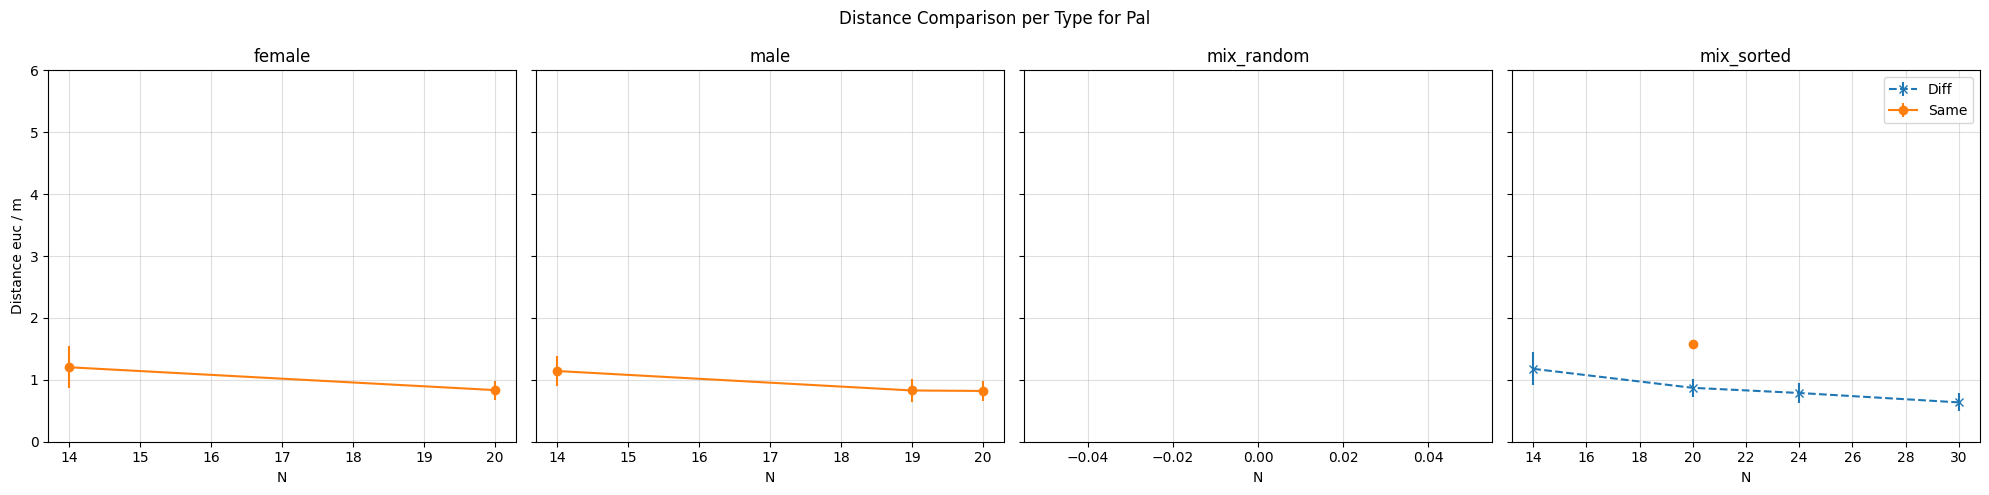

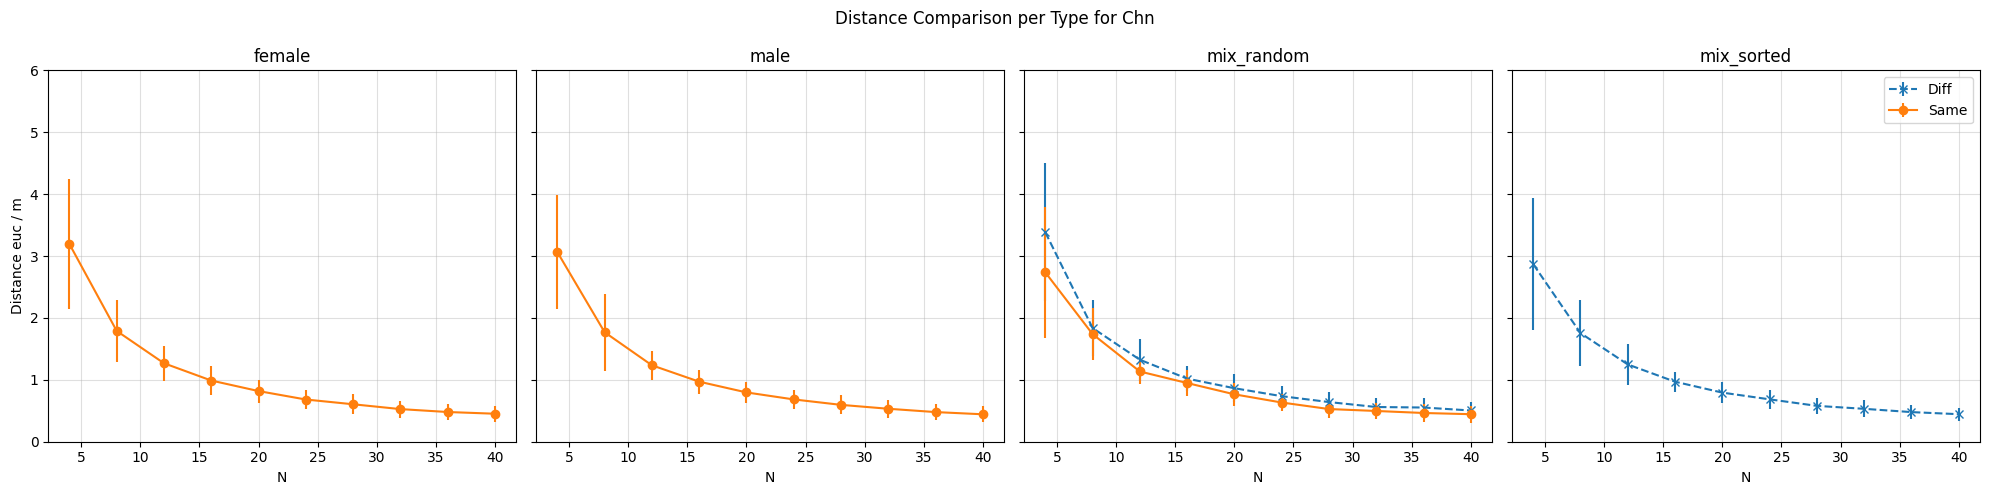

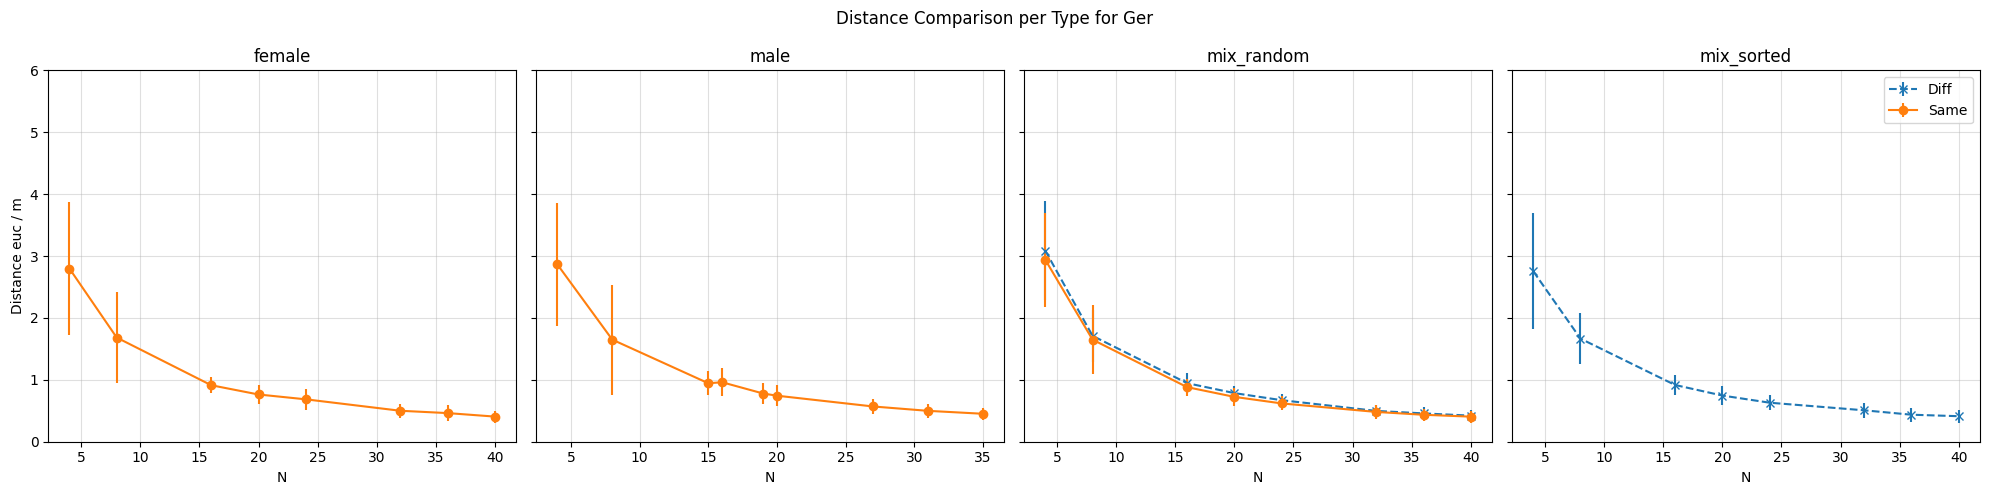

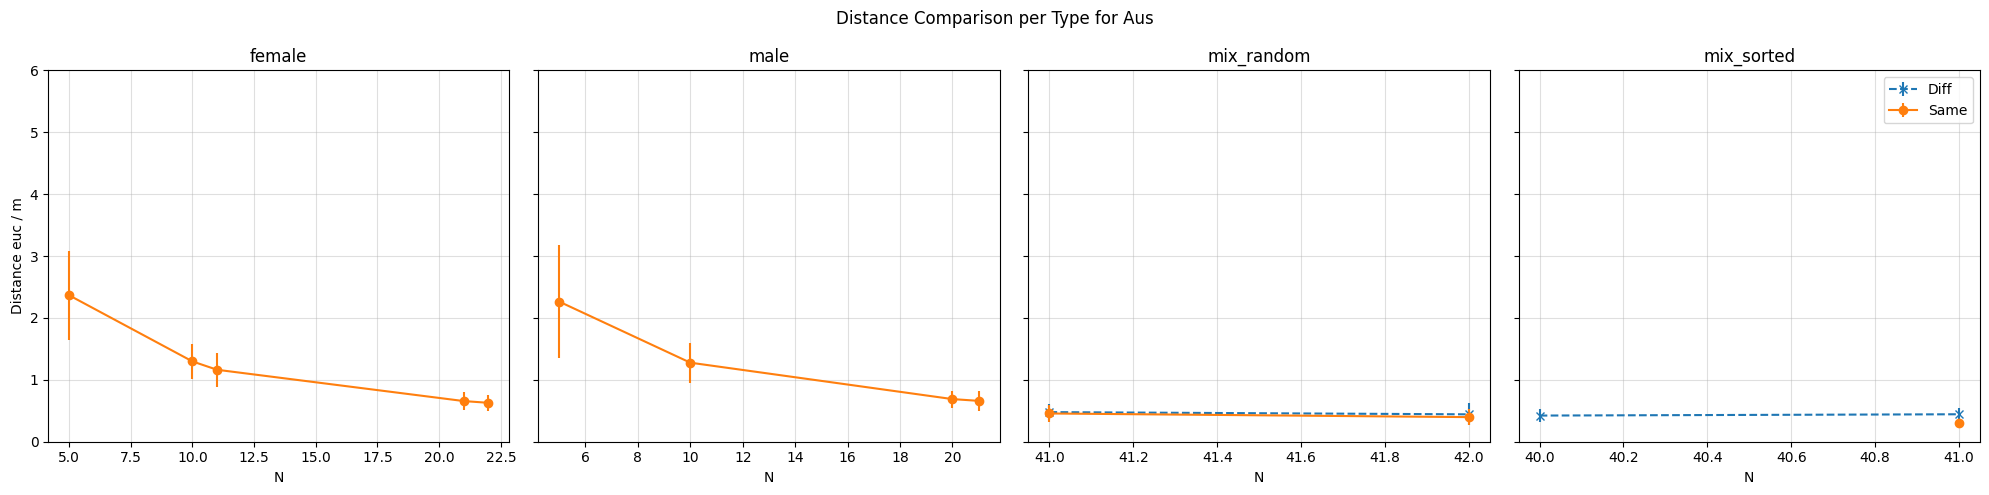

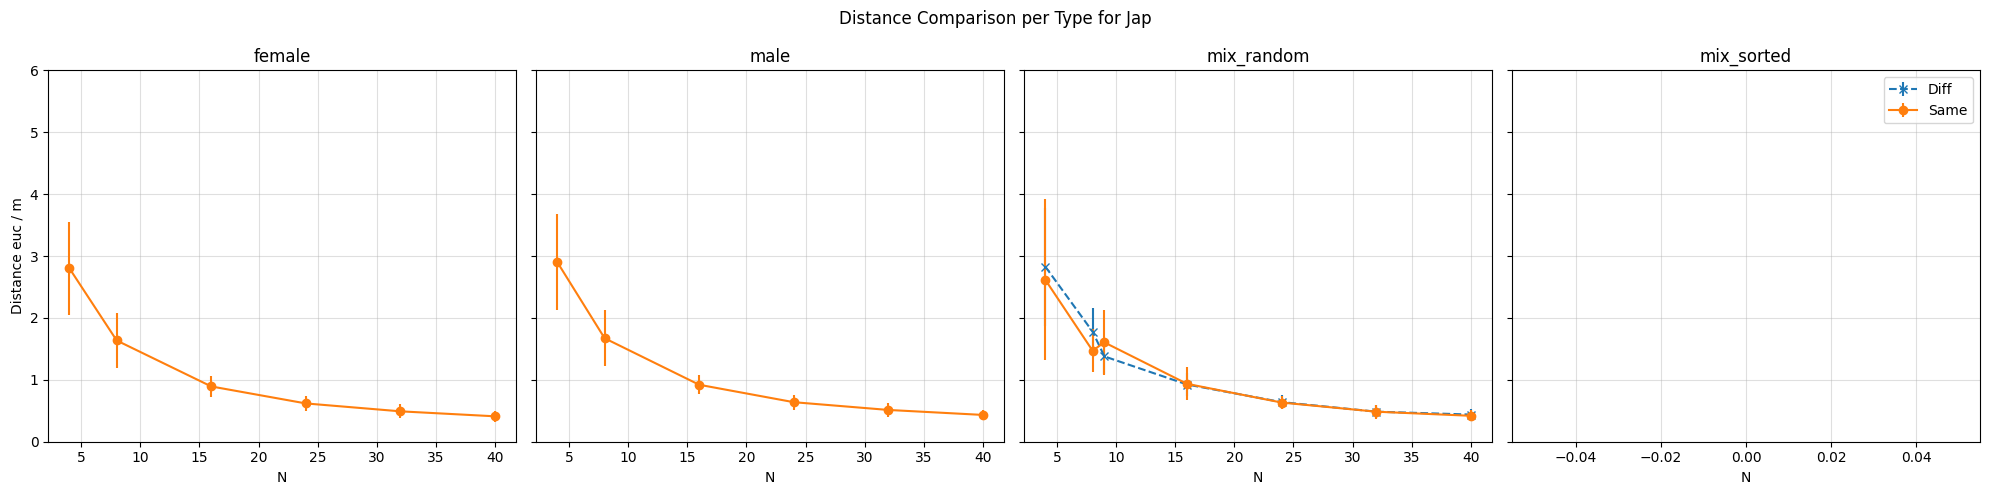

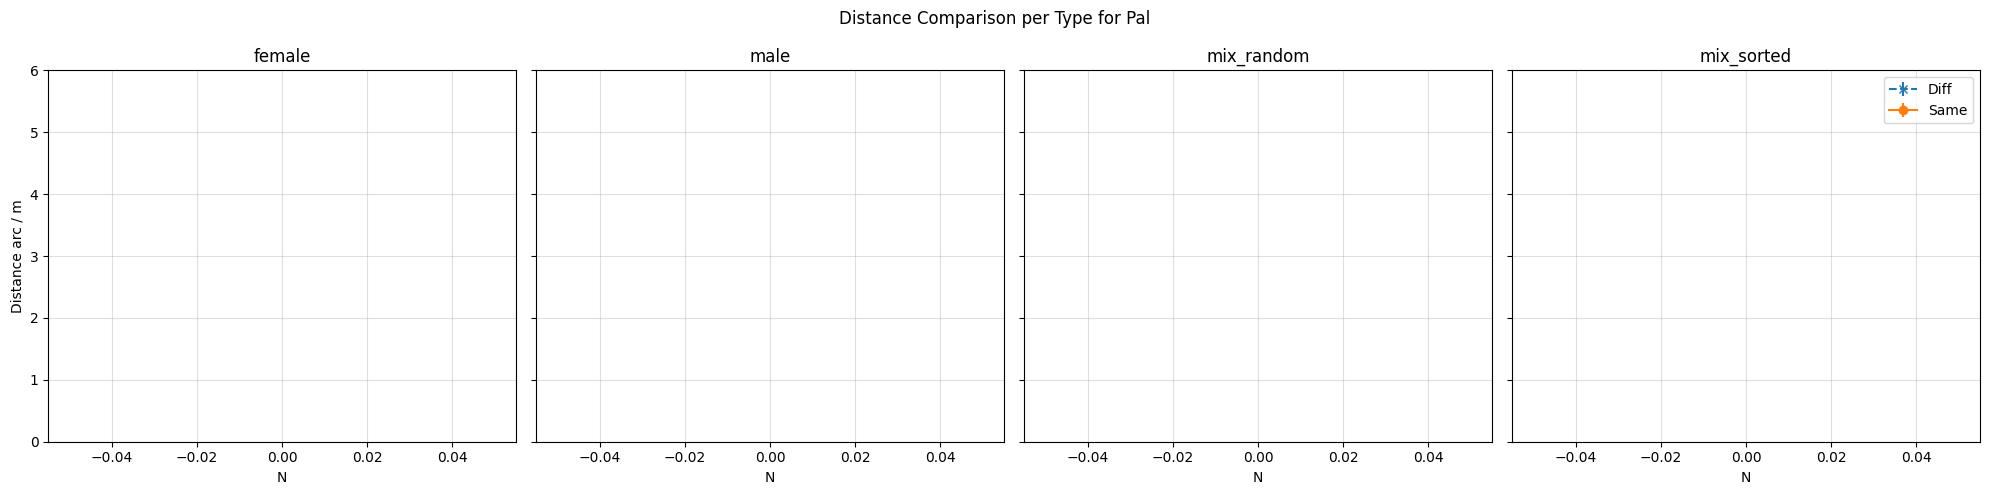

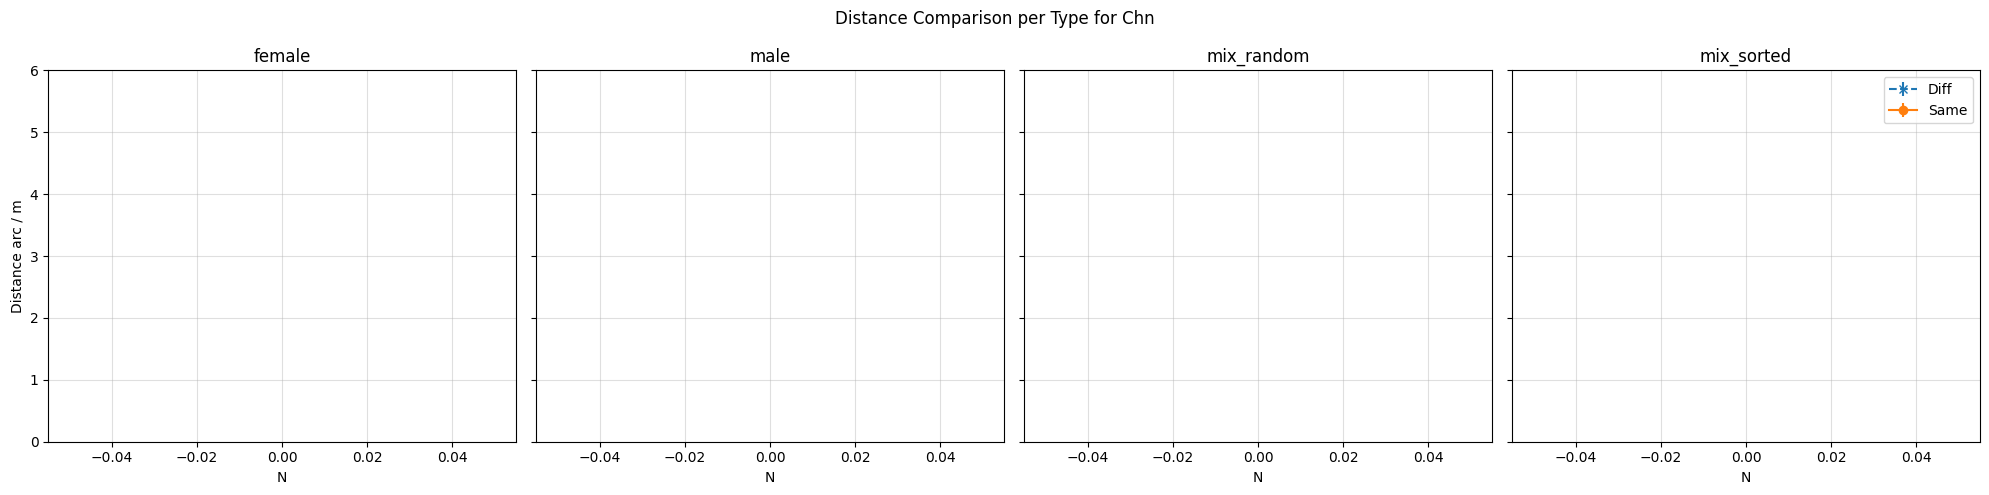

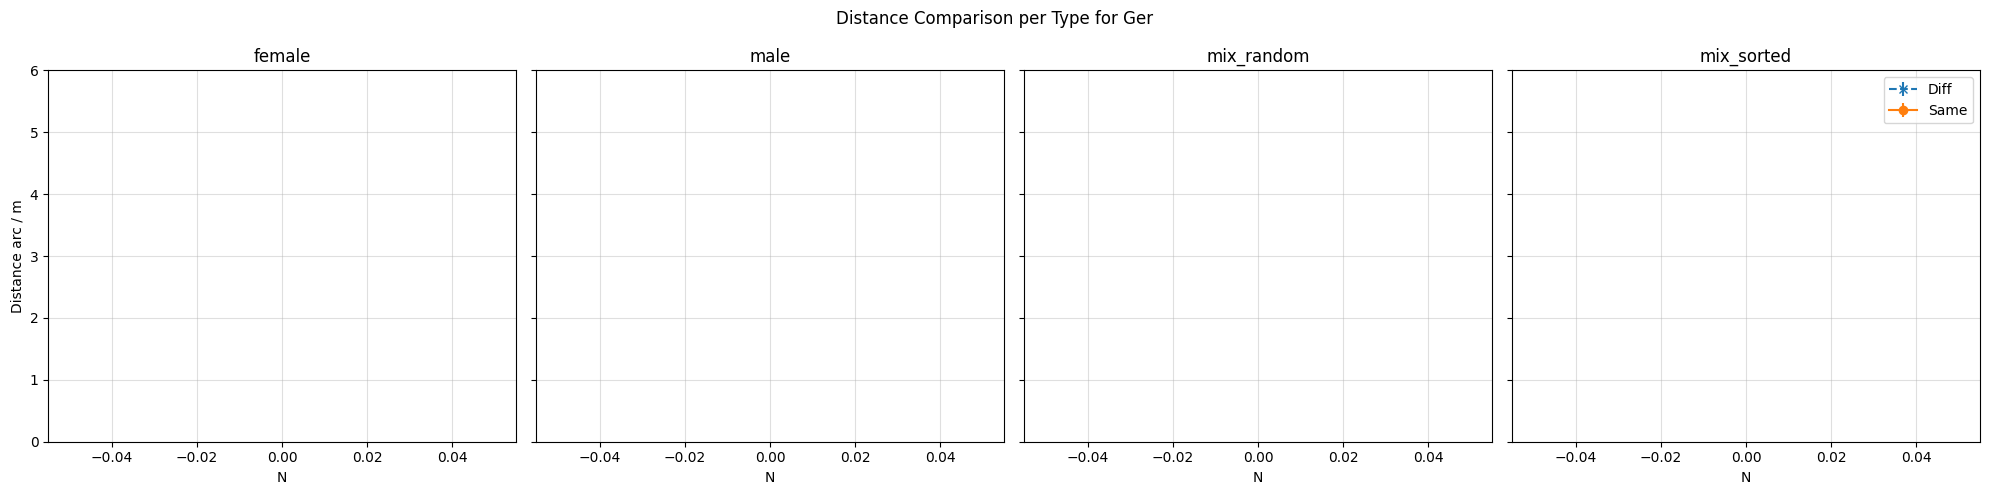

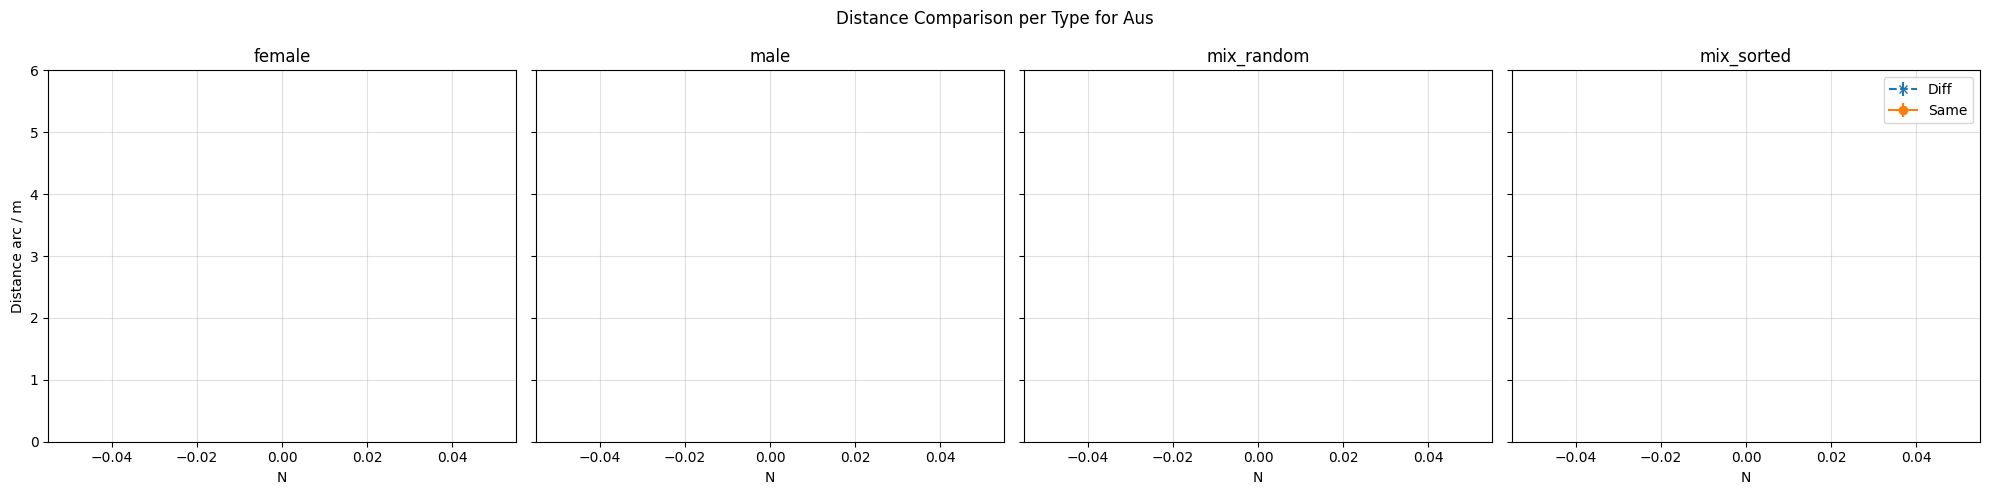

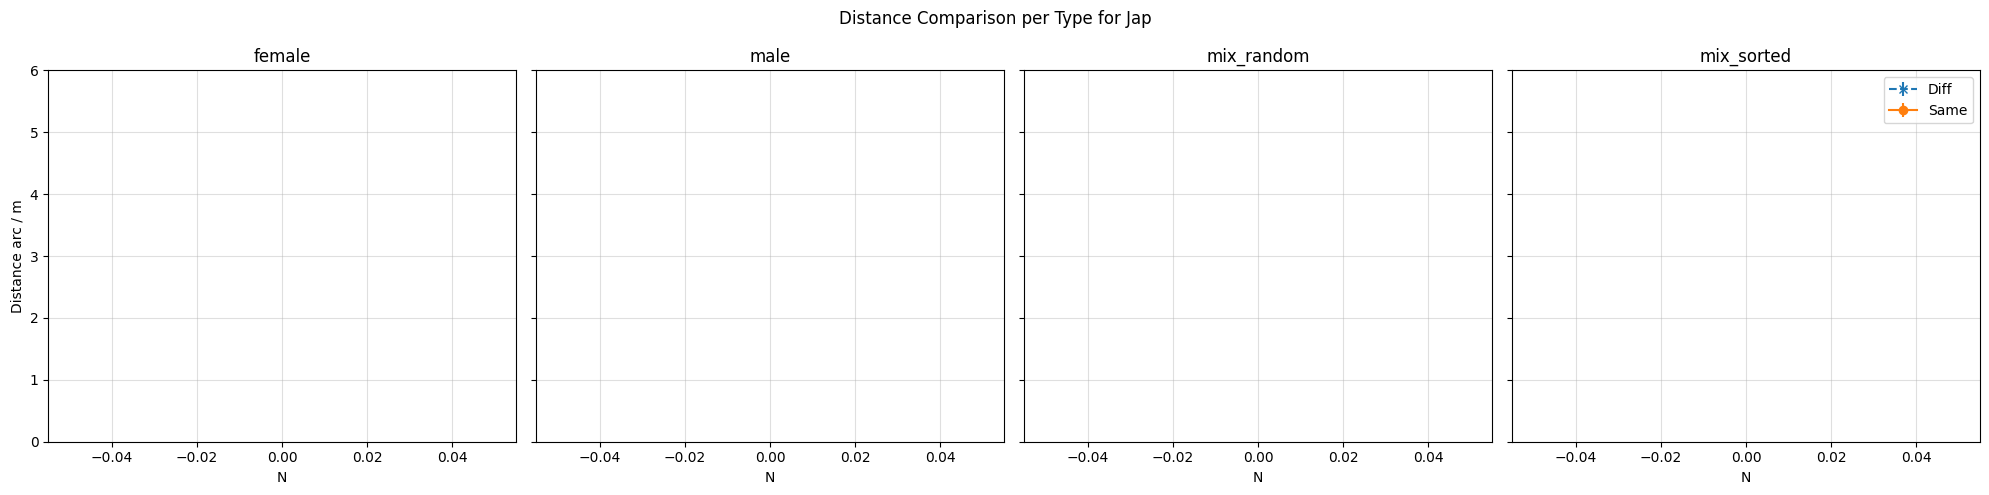

In [4]:
methods = ["euc", "arc"]
for method in methods:
    if method == "euc":
        df = euc.copy( )
    if method == "arc":
        df = arc.copy()

    for country in ["pal", "chn", "ger", "aus", "jap"]:
        figname = f'distance_type_density_{country}_{method}.pdf'
        plot_distance_comparison_by_type(df, country, figname, method)

## Plot distance vs N in ONE figure per type

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_distance_comparison_single_figure(df, country, output_pdf, method):
    """
    Plot distance comparison for all types in a single figure for a given country and save the plot to a PDF file.

    Parameters:
    - df: DataFrame containing the data.
    - country: The country to filter the data by.
    - output_pdf: The path to save the output PDF file.
    """
    plt.figure(figsize=(10, 6))
    plt.title(f'Distance Comparison Across Types for {country.title()}')

    types = sorted(df["type"].unique())
    markers = ['o', 's', '^', 'D', '*']  # Example markers for differentiation
    line_styles = ['-', '--', '-.', ':', '-']  # Example line styles for differentiation

    for i, type_ in enumerate(types):
        df_filtered = df[(df["country"] == country) & (df["type"] == type_)].copy()
        df_filtered['N'] = df_filtered['file'].str.extract(r'_(\d+)_').astype(int)
        Ns = sorted(df_filtered['N'].dropna().unique())

        means_diff = []
        stds_diff = []
        means_same = []
        stds_same = []

        for N in Ns:
            df_n = df_filtered[df_filtered['N'] == N]

            mean_diff = df_n["diff_gender_proximity_next"].mean()
            std_diff = df_n["diff_gender_proximity_next"].std()
            mean_same = df_n["same_gender_proximity_next"].mean()
            std_same = df_n["same_gender_proximity_next"].std()

            means_diff.append(mean_diff)
            stds_diff.append(std_diff)
            means_same.append(mean_same)
            stds_same.append(std_same)

        # Plotting with error bars, using different markers/lines for each type
        plt.errorbar(Ns, means_diff, yerr=stds_diff, label=f'{type_} Diff', fmt=markers[i], linestyle=line_styles[i])
        plt.errorbar(Ns, means_same, yerr=stds_same, label=f'{type_} Same', fmt=markers[i], linestyle=line_styles[i])

    plt.xlabel('N')
    plt.ylabel(f'Distance {method} / m')
    plt.ylim(0, 4)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_pdf)
    plt.show()


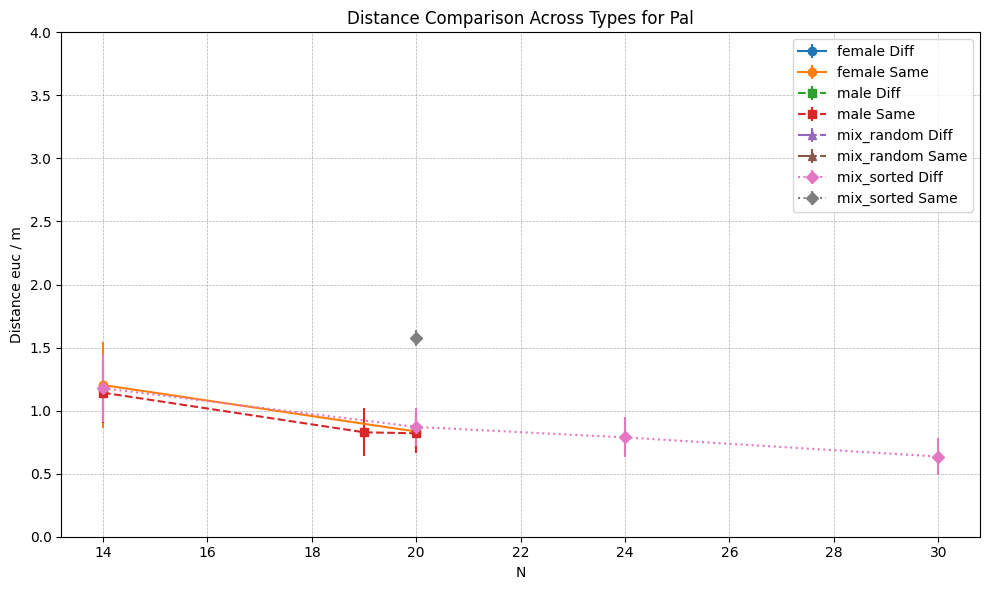

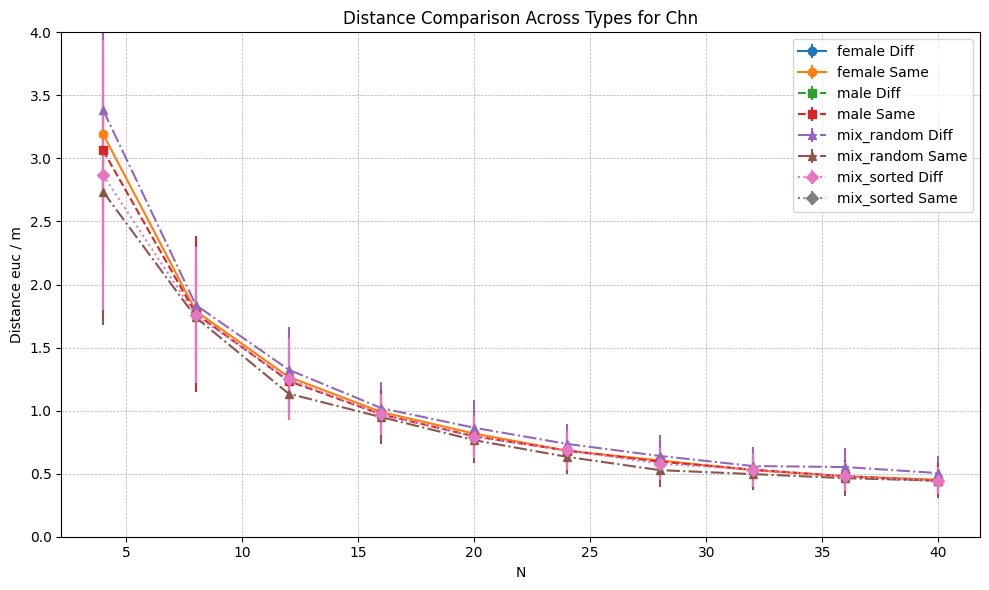

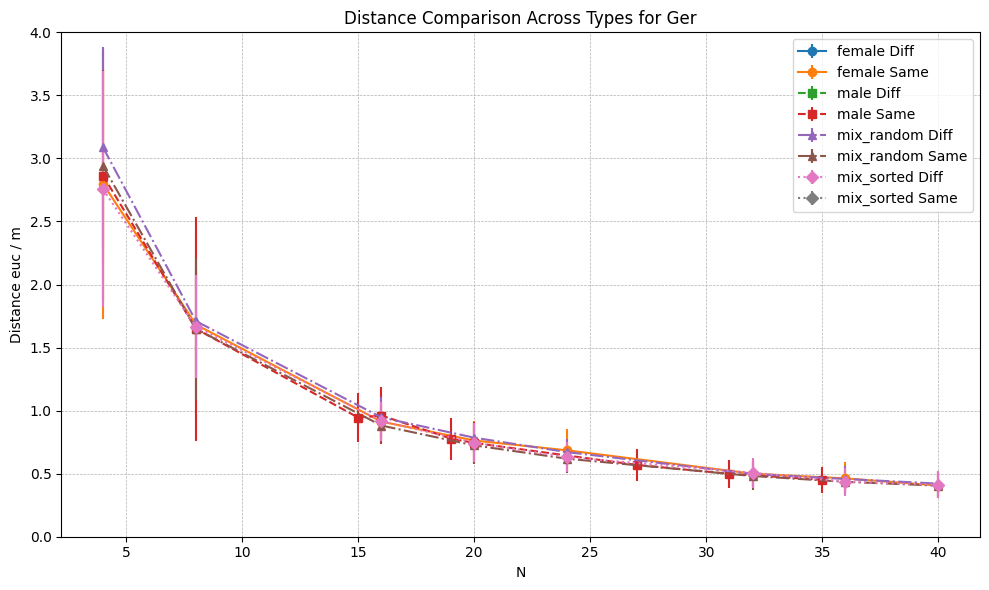

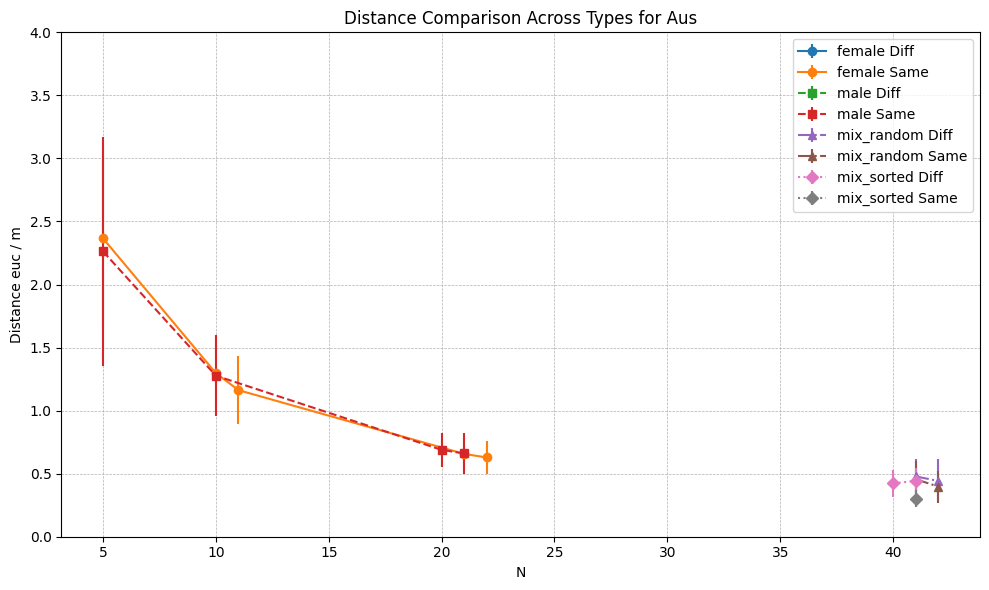

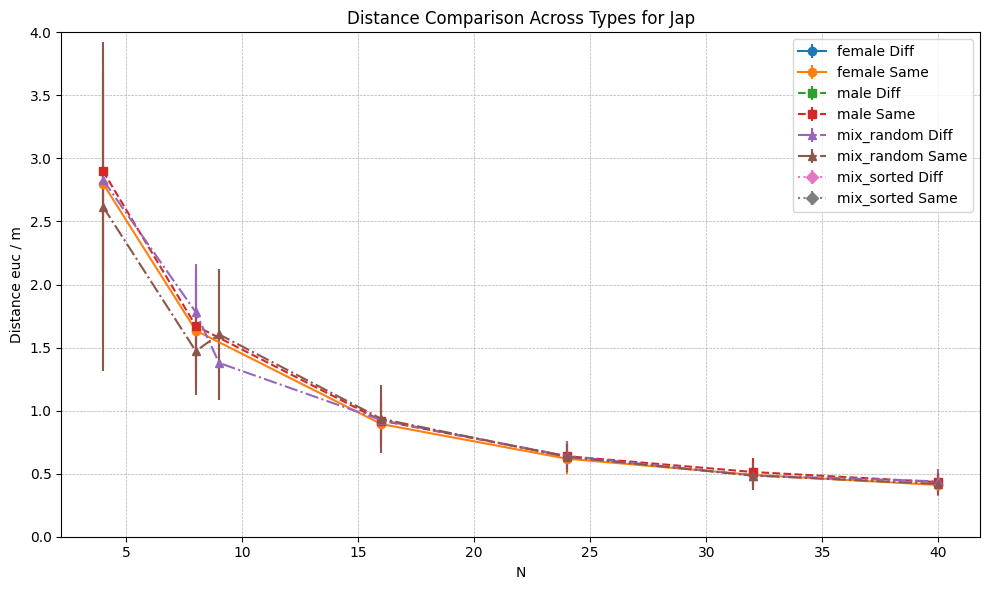

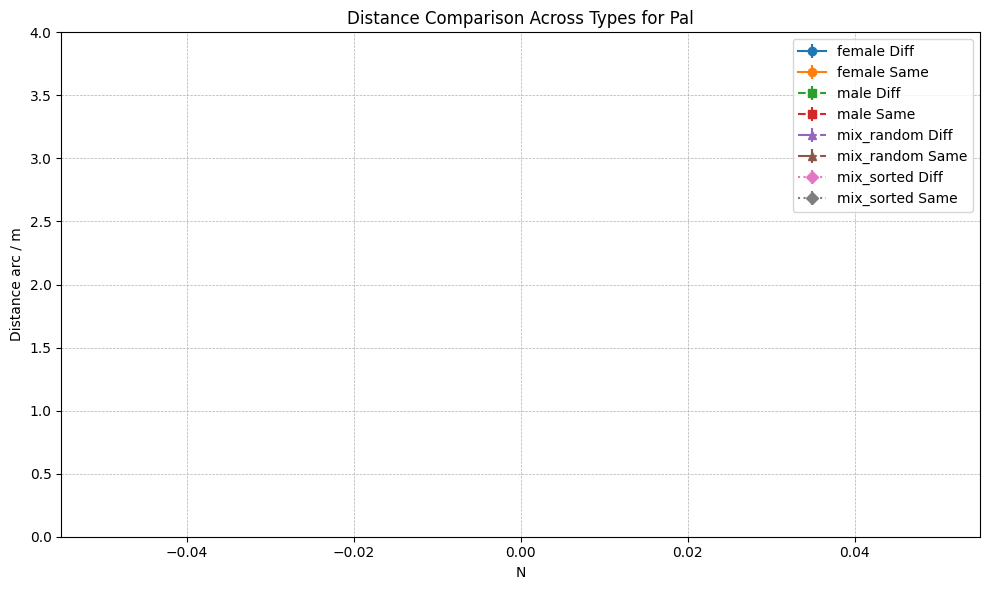

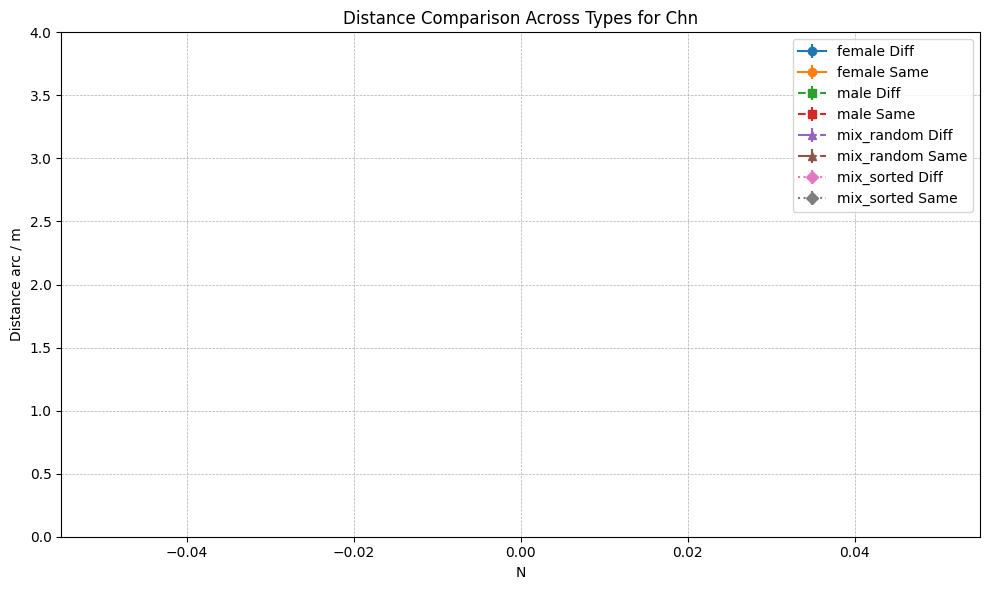

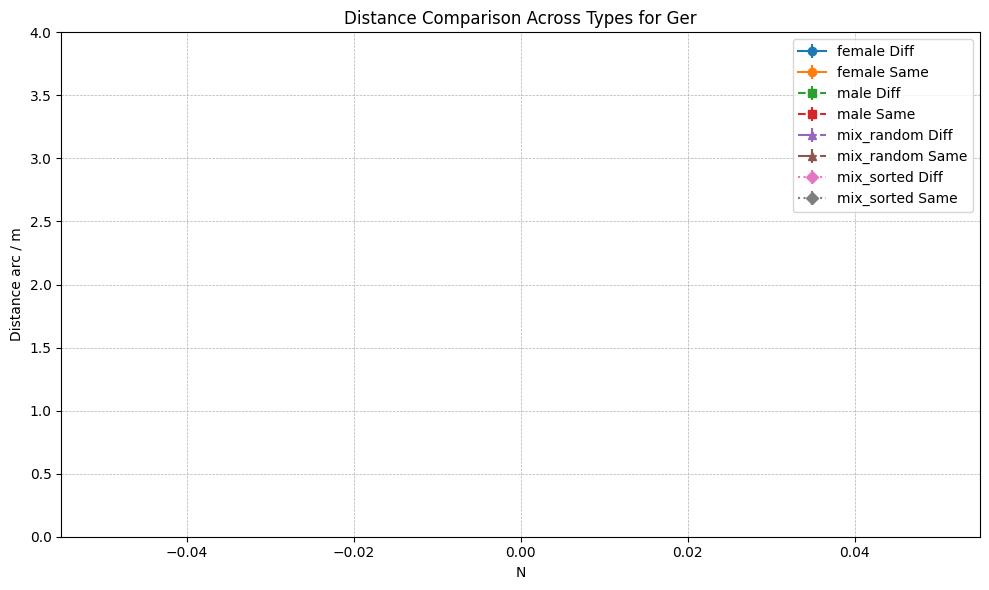

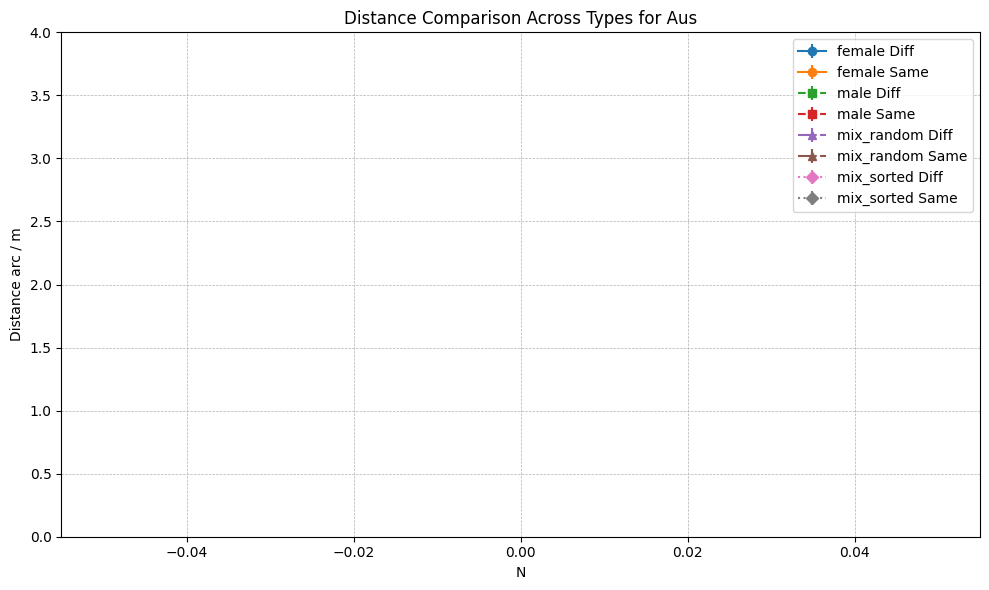

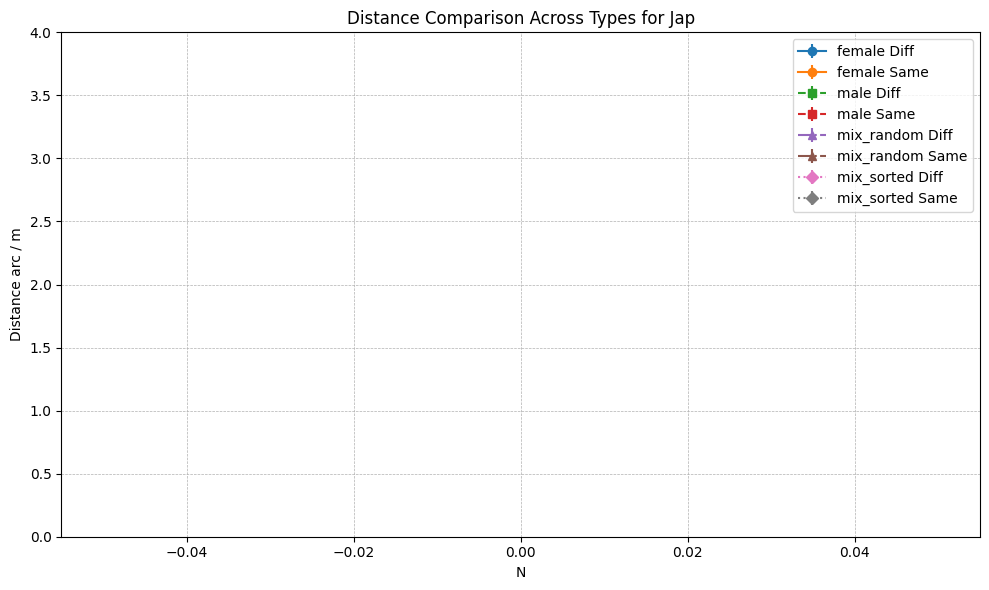

In [6]:
methods = ["euc", "arc"]
for method in methods:
    if method == "euc":
        df = euc.copy( )
    if method == "arc":
        df = arc.copy()

    for country in ["pal", "chn", "ger", "aus", "jap"]:
        figname = f'distance_comparison_single_figure_{country}_{method}.pdf'
        plot_distance_comparison_single_figure(df, country, figname, method)
